# Inwiefern besteht ein Zusammenhang zwischen der Brutto CO2 Einspeisung, Trockenheit, Pflanzenmenge und der Bodentemperatur in Deutschland?

### bezogen auf die Hitzewelle 2018 in Deutschland

Was brauchen wir?

Erstmal: GPP Vergleich mit Trockenheit. Dafür: zwei Karten. Graph (Durschnittliche Trockenheit in Deutschland + Durschnittlicher GPP in Deutschland)

Plan::: Daten für GPP, Trockenheit, Bodentemperatur download. => auf gleiches Raster interpolieren. => alle drei auf nem Line Graph plotten

- CO2: CLMS_GPP_GLOBAL_300M_10DAILY_V2 2013-present
- Feuchtigkeit: CLMS_SSM_EUROPE_1KM_DAILY_V1 2014-present
- Temperatur: CLMS_LST_TCI_GLOBAL_3KM_10DAILY_V3 2016-present

=> 2016-present?

In [ ]:
GPP_ID = "CLMS_GPP_GLOBAL_300M_10DAILY_V2"
SWI_ID = "CLMS_SWI_EUROPE_1KM_DAILY_V1"
LST_ID = "CLMS_LST_TCI_GLOBAL_3KM_10DAILY_V3"

In [126]:
spatial_extent = {
    'west': 5,
    'south': 46,
    'east': 15.5,
    'north': 56,
}

In [127]:
temporal_extent = ["2018-01-01", "2020-12-31"]

Imports

In [128]:
import folium
import geopandas as gpd
import json
import leafmap
import math
import matplotlib.pyplot as plt
import os
import openeo
import pyproj
import rasterio

from rasterio.plot import show
from shapely.geometry import Polygon
from datetime import datetime

Authentification

In [129]:
from openeo.rest.auth.config import RefreshTokenStore

connection = openeo.connect("openeofed.dataspace.copernicus.eu")
connection.authenticate_oidc()
print(connection.describe_account())

Authenticated using refresh token.
{'info': {'oidc_userinfo': {'email': 'moritz.fechte@icloud.com', 'email_verified': True, 'family_name': 'Fe', 'given_name': 'Mo', 'name': 'Mo Fe', 'preferred_username': 'moritz.fechte@icloud.com', 'sub': '01b88e4b-35a5-4da2-8e10-edc6a6ce408f'}}, 'name': 'Mo Fe', 'user_id': '01b88e4b-35a5-4da2-8e10-edc6a6ce408f'}


### Datacube Preprocessing Methoden

Deutschland ausschneiden (germany.geojson Datei notwendig)

In [130]:
def get_german_geometry():
    germany = gpd.read_file("germany.geojson")
    return germany.geometry.iloc[0].__geo_interface__

def mask_germany(datacube, german_geometry):
    return datacube.mask_polygon(
        german_geometry,
        srs="EPSG:4326"
    )

Zeit auf 10 Tage Intervall reduzieren

In [131]:
def reduce_to_decad(datacube):
    return datacube.aggregate_temporal_period(
        period="dekad",
        reducer="mean"
    )

Auflösung auf 1km reduzieren (resamplen)

In [132]:
def align_to_other_cube(grid_providing_cube, cube):
    return cube.resample_cube_spatial(
        target=grid_providing_cube,
        method="average"
    )

In [133]:
def get_mean(datacube, german_geometry):
    return datacube.aggregate_spatial(
        geometries=german_geometry,
        reducer='mean',
    )

### GPP Download

In [ ]:
def load_datacubes():
    gpp = connection.load_collection(
        GPP_ID,
        spatial_extent=spatial_extent,
        temporal_extent = temporal_extent,
        bands=["gpp"],
    )

    ssm = connection.load_collection(
        SWI_ID,
        spatial_extent=spatial_extent,
        temporal_extent=temporal_extent,
        bands=["swi020"],
    )

    lst = connection.load_collection(
        LST_ID,
        spatial_extent=spatial_extent,
        temporal_extent=temporal_extent,
        bands=["tci_median"],
    )

    return gpp, ssm, lst

In [ ]:
# preprocessing execution
def preprocess_maps(gpp, ssm, lst, german_geometry):
    # select bands
    gpp = gpp.band('gpp')
    swi = ssm.band('swi020')
    lst = lst.band('tci_median')

    gpp = reduce_to_decad(gpp)
    gpp = align_to_other_cube(swi, gpp)
    gpp = mask_germany(gpp, german_geometry)

    swi = reduce_to_decad(swi)
    swi = mask_germany(swi, german_geometry)

    lst = reduce_to_decad(lst)
    lst = align_to_other_cube(swi, lst)
    lst = mask_germany(lst, german_geometry)

    return gpp, swi, lst

def download_means(gpp, swi, lst, german_geometry):
    print('downloading gpp')
    gpp_means = get_mean(gpp, german_geometry).execute()
    with open('means/gppmeans.json', "w") as file:
        json.dump(gpp_means, file, indent=4)
    print('downloading swi')
    swi_means = get_mean(swi, german_geometry).execute()
    with open('means/swimeans.json', "w") as file:
        json.dump(swi_means, file, indent=4)
    print('downloading lst')
    lst_means = get_mean(lst, german_geometry).execute()
    with open('means/lstmeans.json', "w") as file:
        json.dump(lst_means, file, indent=4)
    print('done')

    return lst_means



# gpp.download('gpp.tif')

computing und downloaden

In [ ]:
gpp, swi, lst = load_datacubes()
german_geometry = get_german_geometry()
gpp, swi, lst = preprocess_maps(gpp, swi, lst, german_geometry)
lst_means = download_means(gpp, swi, lst, german_geometry)

downloading gpp
downloading ssm
downloading lst
done


import json means

In [ ]:
with open('means/gppmeans.json', 'r') as file:
    gpp_means = json.load(file)
with open('means/gppmeans.json', 'r') as file:
    swi_means = json.load(file)
with open('means/lstmeans.json', 'r') as file:
    lst_means = json.load(file)

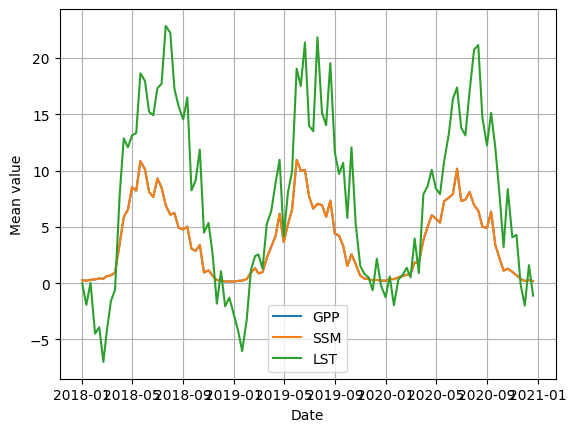

In [ ]:
def extract_data(data): 
    dates = [datetime.fromisoformat(date.replace("Z", "+00:00")) for date in data] 
    values = [value[0][0] for value in data.values()] 
    return dates, values 

gpp_dates, gpp_values = extract_data(gpp_means) 
swi_dates, swi_values = extract_data(ssm_means) 
lst_dates, lst_values = extract_data(lst_means)

#converting lst temp from K into C
for i in range(len(lst_values)):
    lst_values[i] -= 273.15

plt.plot(gpp_dates, gpp_values, label="GPP") 
plt.plot(swi_dates, ssm_values, label="SSM") 
plt.plot(lst_dates, lst_values, label="LST") 
plt.xlabel("Date") 
plt.ylabel("Mean value") 
plt.legend() 
plt.grid() 
plt.show()